## Overview
This notebook implements an automated pipeline to solve the **ML-CUP25 Regression Task** using an **Ensemble of Small Models**.

## Workflow
1.  **Data Loading**: 
    - Loads `ML-CUP25-TR.csv` and splits it into **Train**, **Validation** (20%), and **Blind Test**.

2.  **Architecture Search (Optuna)**: 
    - We use **Optuna** to find the best hyperparameters for a *single* small model.
    - **Constraints**: 
        - Depth: 1 to 2 hidden layers.
        - Width: 8 to 64 neurons per layer.
    - **Goal**: Minimize MSE on the Validation Set.

3.  **Ensemble Training**: 
    - We take the *best* architecture found by Optuna.
    - We instantiate **5 independent copies** of this model (the "Ensemble").
    - Each copy is trained from scratch with different random initializations.

4.  **Final Evaluation**:
    - The ensemble's prediction is the **average** of all 5 members.
    - We report the final MSE on the Validation and Test sets.

## How to Use
1.  **Prerequisites**: Ensure `data_loader.py` and the `models/` folder are in the same directory.
2.  **Configuration**: Adjust the constants in the first code cell (e.g., `N_TRIALS`, `ENSEMBLE_SIZE`) to control runtime.
3.  **Run All**: Execute all cells in order. The Optuna search will run first, followed automatically by the ensemble training.

In [18]:
#--- IMPORTS ---
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import matplotlib.pyplot as plt
import sys
from sklearn.decomposition import PCA

# Ensure we can import from local modules
sys.path.append(os.getcwd())

# Import your custom modules
from utils.data_loader import get_ml_cup_data, get_monk_data
from models import StandardFeedForwardNet, EnsembleModel
from models.ensemble import ModelWithHead, ReadoutAdapter
import utils.training_utils as training_utils
from utils.training_utils import evaluate_mee
from utils.project_utils import update_json, standard_plot, plot_confusion_matrix

# --- CONFIGURATION ---
N_TRIALS = 150
N_EPOCHS_SEARCH = 100
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# Global Plot Settings
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


Using device: mps


## Part 1: Monk

In [ ]:
# --- MONK ---
# 1. Load Data
monk_results = {}

experiments = [
    {'id': 1, 'reg': False, 'name': 'Monk-1'},
    {'id': 2, 'reg': False, 'name': 'Monk-2'},
    {'id': 3, 'reg': False, 'name': 'Monk-3'},
    {'id': 3, 'reg': True, 'name': 'Monk-3-Reg'}
]

for exp in experiments:
    monk_id = exp['id']
    is_reg = exp['reg']
    task_name = exp['name']
    
    print(f"\n--- Analyzing {task_name} ---")
    # Ensure BATCH_SIZE is defined, otherwise default to 64
    bs = BATCH_SIZE if 'BATCH_SIZE' in globals() else 64
    train_loader, test_loader, input_size, output_size = get_monk_data(monk_id, bs)
    
    # 2. Define Model (Simple MLP)
    class MonkMLP(nn.Module):
        def __init__(self, input_size, hidden_units):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_size, hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, 1), # Binary classification
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.net(x)

    # 3. Grid Search (Manual)
    learning_rates = [0.01, 0.1]
    momentums = [0.9]
    hidden_units_list = [4, 8]
    weight_decays = [0.0] if not is_reg else [0.1, 0.5]
    epochs_list = [100]
    
    best_acc = 0.0
    best_config = {}
    best_history = {}
    
    for lr in learning_rates:
        for mom in momentums:
            for hu in hidden_units_list:
                for wd in weight_decays:
                    for epochs in epochs_list:
                        model = MonkMLP(input_size, hu).to(DEVICE)
                        criterion = nn.BCELoss()
                        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=mom, weight_decay=wd)
                        
                        history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
                        
                        # Train for fixed epochs
                        for epoch in range(epochs):
                            model.train()
                            train_loss = 0
                            correct = 0
                            total = 0
                            for x, y in train_loader:
                                x, y = x.to(DEVICE), y.to(DEVICE).float().unsqueeze(1)
                                optimizer.zero_grad()
                                out = model(x)
                                loss = criterion(out, y)
                                loss.backward()
                                optimizer.step()
                                train_loss += loss.item()
                                predicted = (out > 0.5).float()
                                correct += (predicted == y).sum().item()
                                total += y.size(0)
                            
                            history['loss'].append(train_loss / len(train_loader))
                            history['accuracy'].append(correct / total)
                            
                            # Validation (Test set as validation for Monk)
                            model.eval()
                            val_loss = 0
                            correct = 0
                            total = 0
                            with torch.no_grad():
                                for x, y in test_loader:
                                    x, y = x.to(DEVICE), y.to(DEVICE).float().unsqueeze(1)
                                    out = model(x)
                                    loss = criterion(out, y)
                                    val_loss += loss.item()
                                    predicted = (out > 0.5).float()
                                    correct += (predicted == y).sum().item()
                                    total += y.size(0)
                            
                            history['val_loss'].append(val_loss / len(test_loader))
                            history['val_accuracy'].append(correct / total)
                        
                        final_acc = history['val_accuracy'][-1]
                        if final_acc > best_acc:
                            best_acc = final_acc
                            best_config = {'lr': lr, 'momentum': mom, 'hidden_units': hu, 'weight_decay': wd, 'epochs': epochs}
                            best_history = history
    
    print(f"Best Config for {task_name}: {best_config}, Acc: {best_acc}")
    
    # 4. Save Results
    standard_plot(best_history, f"{task_name} Best Model", f"{task_name.lower().replace('-', '_')}_pytorch.png")
    update_json(task_name, "PyTorch", {"test_accuracy": best_acc, "config": best_config})

    
    # Re-train best model for Confusion Matrix
    print(f"Generating Confusion Matrix for {task_name}...")
    best_lr = best_config['lr']
    best_mom = best_config['momentum']
    best_hu = best_config['hidden_units']
    best_wd = best_config['weight_decay']
    best_epochs = best_config['epochs']
    
    model = MonkMLP(input_size, best_hu).to(DEVICE)
    optimizer = optim.SGD(model.parameters(), lr=best_lr, momentum=best_mom, weight_decay=best_wd)
    criterion = nn.BCELoss()
    
    for epoch in range(best_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE).float().unsqueeze(1)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
    # Predict
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in test_loader: # Test loader is validation for Monk
            x = x.to(DEVICE)
            out = model(x)
            all_preds.extend(out.cpu().numpy().flatten())
            all_targets.extend(y.numpy().flatten())
            
    plot_confusion_matrix(all_targets, all_preds, f"{task_name} Best Model", f"{task_name.lower().replace('-', '_')}_pytorch_cm.png")


# Part 2: ML-CUP

## Grid Search vs Randomized vs Optuna Comparison\n
Before running the full randomized search, we perform a direct comparison between **Grid Search**, **Randomized search** and **Optuna**.\n
We use a expanded budget of **288 trials** for all methods.\n
\n
- **Grid Search**: Exhaustive search over the discrete grid.\n
- **Randomized & Optuna**: Continuous search within the ranges defined by the grid boundaries.\n
\n
**Search Space:**\n
- **Hidden Units**: Fixed at 16\n
- **LR**: Grid [1e-4 .. 5e-2] | Continuous Log-Uniform [1e-4, 5e-2]\n
- **Momentum**: Grid [0.5 .. 0.9] | Continuous Uniform [0.5, 0.9]\n
- **Weight Decay**: Grid [0.0 .. 1e-1] | Continuous Log-Uniform [1e-5, 1e-1]\n
- **Activation**: ['relu', 'tanh']\n

In [ ]:
# --- GRID SEARCH vs OPTUNA COMPARISON ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import time
import random
from copy import deepcopy

# 1. Setup Data for Comparison
print("--- Starting Grid Search vs Optuna vs Random Search Comparison (288 Trials each) ---")
# Capture the scaler
train_loader_cmp, val_loader_cmp, _, input_size_cmp, output_size_cmp, target_scaler_cmp = get_ml_cup_data(BATCH_SIZE, validation_ratio=0.2, test_ratio=0.1, num_workers=0)

# Define Search Space
grid_space = {
    'lr': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2],
    'momentum': [0.5, 0.7, 0.8, 0.9],
    'weight_decay': [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'activation': ['relu', 'tanh']
}
fixed_hidden_units = 16

N_EPOCHS_COMPARE = 20

def train_and_eval(params):
    # Activation
    act_fn = nn.ReLU() if params['activation'] == 'relu' else nn.Tanh()
    
    # Model
    model = nn.Sequential(
        nn.Linear(input_size_cmp, fixed_hidden_units),
        act_fn,
        nn.Linear(fixed_hidden_units, fixed_hidden_units),
        act_fn,
        nn.Linear(fixed_hidden_units, output_size_cmp)
    ).to(DEVICE)
    
    optimizer = optim.SGD(model.parameters(), lr=params['lr'], momentum=params['momentum'], weight_decay=params['weight_decay'])
    criterion = nn.MSELoss() # Train with MSE
    
    # Train
    model.train()
    for epoch in range(N_EPOCHS_COMPARE):
        for x, y in train_loader_cmp:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
    # Eval (Calculate MEE Unscaled)
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in val_loader_cmp:
            x = x.to(DEVICE)
            out = model(x)
            all_preds.append(out.cpu())
            all_targets.append(y.cpu())
            
    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    
    # Inverse Scale if needed
    if target_scaler_cmp:
        preds = target_scaler_cmp.inverse_transform(preds)
        targets = target_scaler_cmp.inverse_transform(targets)
        
    # Calculate MEE
    # MEE = Mean of Euclidean Distances per sample
    errors = np.linalg.norm(preds - targets, axis=1)
    mee = np.mean(errors)
    
    return mee

# --- 2. GRID SEARCH (Discrete) ---
print("Running Grid Search (Discrete Grid)...")
grid_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
trial_idx = 0
start_time = time.time()

for lr in grid_space['lr']:
    for mom in grid_space['momentum']:
        for wd in grid_space['weight_decay']:
            for act in grid_space['activation']:
                trial_idx += 1
                params = {'lr': lr, 'momentum': mom, 'weight_decay': wd, 'activation': act}
                val_mee = train_and_eval(params)
                
                grid_results['trial'].append(trial_idx)
                grid_results['value'].append(val_mee)
                grid_results['lr'].append(lr)
                grid_results['momentum'].append(mom)
                grid_results['weight_decay'].append(wd)
                grid_results['activation'].append(act)
                if trial_idx % 20 == 0:
                     print(f"Grid Trial {trial_idx}/288: {params} => MEE: {val_mee:.4f}")

grid_time = time.time() - start_time

# --- 2.5. RANDOM SEARCH (Continuous) ---
print("Running Randomized Search (Continuous)...")
random_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
random.seed(42) # Reproducibility
start_time = time.time()

TOTAL_TRIALS = 288

for i in range(TOTAL_TRIALS):
    # Sample Continuously
    r_lr = 10 ** random.uniform(np.log10(1e-4), np.log10(5e-2))
    r_mom = random.uniform(0.5, 0.9)
    r_wd = 10 ** random.uniform(np.log10(1e-5), np.log10(1e-1))
    r_act = random.choice(grid_space['activation'])
    
    params = {'lr': r_lr, 'momentum': r_mom, 'weight_decay': r_wd, 'activation': r_act}
    val_mee = train_and_eval(params)
    
    random_results['trial'].append(i + 1)
    random_results['value'].append(val_mee)
    random_results['lr'].append(r_lr)
    random_results['momentum'].append(r_mom)
    random_results['weight_decay'].append(r_wd)
    random_results['activation'].append(r_act)
    
    if (i+1) % 20 == 0:
        print(f"Random Trial {i+1}/{TOTAL_TRIALS}: {params} => MEE: {val_mee:.4f}")

random_time = time.time() - start_time

# --- 3. OPTUNA SEARCH (Continuous) ---
print("Running Optuna Search (Continuous)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'momentum': trial.suggest_float('momentum', 0.5, 0.9),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True),
        'activation': trial.suggest_categorical('activation', grid_space['activation'])
    }
    return train_and_eval(params)

start_time = time.time()
study_cmp = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_cmp.optimize(objective, n_trials=TOTAL_TRIALS)
optuna_time = time.time() - start_time

# Extract Optuna Results
optuna_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
for t in study_cmp.trials:
    optuna_results['trial'].append(t.number + 1)
    optuna_results['value'].append(t.value)
    optuna_results['lr'].append(t.params['lr'])
    optuna_results['momentum'].append(t.params['momentum'])
    optuna_results['weight_decay'].append(t.params['weight_decay'])
    optuna_results['activation'].append(t.params['activation'])

# --- 4. VISUALIZATION ---
print(f"Comparison Complete.")
print(f"Grid Time: {grid_time:.2f}s")
print(f"Random Time: {random_time:.2f}s")
print(f"Optuna Time: {optuna_time:.2f}s")

# Plot 1: Best Value over Trials
grid_best = np.minimum.accumulate(grid_results['value'])
random_best = np.minimum.accumulate(random_results['value'])
opt_best = np.minimum.accumulate(optuna_results['value'])

plt.figure(figsize=(10, 6))
plt.plot(grid_results['trial'], grid_best, label='Grid Search Best', marker='o')
plt.plot(random_results['trial'], random_best, label='Random Search Best', marker='s', linestyle='-.')
plt.plot(optuna_results['trial'], opt_best, label='Optuna Best', marker='x')
plt.title('Best MEE vs Trial Number')
plt.xlabel('Trial')
plt.ylabel('Best MEE')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: All Trials Values
plt.figure(figsize=(10, 6))
plt.scatter(grid_results['trial'], grid_results['value'], label='Grid', alpha=0.6)
plt.scatter(random_results['trial'], random_results['value'], label='Random', alpha=0.6, marker='s')
plt.scatter(optuna_results['trial'], optuna_results['value'], label='Optuna', alpha=0.6, marker='x')
plt.title('Trial MEE Distribution')
plt.xlabel('Trial')
plt.ylabel('MEE')
plt.legend()
plt.grid(True)
plt.show()

## Optuna search for best model (cup)

In [20]:
# --- RUN OPTUNA SEARCH & ANALYZE TOP 5 MODELS ---
import sys
import optuna
import subprocess
import time
import pandas as pd
from IPython.display import display
from tqdm import tqdm  # progress bar

# 1. Run the external script in a background process
print(f"Starting Optuna Search (External Script)...")
# Get current environment and add the current directory (Project Root) to PYTHONPATH
my_env = os.environ.copy()
my_env["PYTHONPATH"] = os.getcwd()

cmd = [sys.executable, "utils/optuna_search_mlcup_nn.py", "--n_trials", str(N_TRIALS), "--epochs", str(N_EPOCHS_SEARCH)]

# Pass the modified environment to the subprocess
process = subprocess.Popen(cmd, env=my_env)

# 2. Monitor Progress Bar
db_url = "sqlite:///optuna_mlcup_nn.db"
pbar = tqdm(total=N_TRIALS, desc="Optuna Trials", unit="trial")

try:
    while process.poll() is None:  # Keep running while the subprocess is alive
        try:
            # Connect to DB securely
            temp_storage = optuna.storages.RDBStorage(url=db_url)
            
            try:
                study_temp = optuna.load_study(study_name="mlcup_search", storage=temp_storage)
                current_trials = len(study_temp.trials)
                pbar.n = current_trials
                pbar.refresh()
            except (KeyError, ValueError):
                pass
            
            # Dispose to release lock
            temp_storage.engine.dispose()
            del temp_storage
            
        except Exception:
            pass
            
        time.sleep(2)

except KeyboardInterrupt:
    print("Stopping external script...")

pbar.n = N_TRIALS 
pbar.refresh()
pbar.close()
print("External script finished.")

# 3. Access Results Safely
storage = optuna.storages.RDBStorage(url=db_url)

try:
    study = optuna.load_study(study_name="mlcup_search", storage=storage)
    df = study.trials_dataframe()
    df = df[df.state == "COMPLETE"]
    
    if not df.empty:
        top_5 = df.sort_values('value', ascending=True).head(5)
        cols_to_show = ['number', 'value'] + [c for c in df.columns if c.startswith('params_')]

        print(f"\nSearch Complete. Best Params: {study.best_params}")
        display(top_5[cols_to_show])
        best_params = study.best_params
    else:
        print("No complete trials found.")

finally:
    storage.engine.dispose()
    del storage

Starting Optuna Search (External Script)...


Optuna Trials:   1%|          | 1/150 [00:02<05:08,  2.07s/trial]/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Optuna Trials:   1%|          | 1/150 [00:06<15:19,  6.17s/trial]

⚠️  Warning: Keras/TensorFlow utils not loaded. Reason: No module named 'tensorflow.keras'
Loading RAW data on cpu for dynamic scaling...
Parsing ML-CUP data (TR only)...
Data Split: Train=400, Val=0, Internal Test=100
--- PCA DISABLED ---
Starting Search: Trials=150, Epochs=100, Study=mlcup_search


Optuna Trials: 151trial [06:54,  2.74s/trial]                      

Search complete.
Study results saved to pytorch/models/optuna/mlcup_search/optuna_results.csv
Best params saved to pytorch/models/optuna/mlcup_search/hp.json


Optuna Trials: 100%|██████████| 150/150 [06:58<00:00,  2.79s/trial]

External script finished.

Search Complete. Best Params: {'scaler': 'standard', 'scale_target': True, 'gaussian_noise': 0.0632636216524357, 'hidden_size': 14, 'dropout': 0.10217150942682192, 'weight_decay': 6.3269102971301685e-06, 'activation': 'silu', 'lr': 0.08987628079997402}


,number,value,params_activation,params_dropout,params_gaussian_noise,params_hidden_size,params_lr,params_scale_target,params_scaler,params_weight_decay
100,100,174.142487,silu,0.102172,0.063264,14.0,0.089876,True,standard,0.000006
106,106,175.502029,silu,0.113091,0.060501,13.0,0.085949,True,standard,0.000005
92,92,175.760941,silu,0.120093,0.067128,14.0,0.097338,True,standard,0.000010
132,132,175.762787,silu,0.106720,0.061869,13.0,0.091960,True,standard,0.000008
93,93,176.172760,silu,0.153290,0.063775,14.0,0.098127,True,standard,0.000007


In [12]:
# --- 3. TRAINING FINAL SINGLE MODEL ---
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA

# Import custom modules
from models import StandardFeedForwardNet, ModelWithHead, ReadoutAdapter
from utils.data_loader import MLCupDataset, get_ml_cup_data, GaussianNoise
import utils.training_utils as training_utils

# --- SETTINGS ---
N_EPOCHS_FINAL = 2000
PATIENCE = 100           # Early stopping patience
MODEL_SAVE_PATH = "models/best_pytorch_mlcup.pth"

# 1. Retrieve Best Hyperparameters
if 'study' in globals():
    params = study.best_params
    print(f"Using Best Params from Optuna: {params}")
else:
    # Fallback if study not run
    print("Warning: Optuna study not found. Using default params.")
    params = {'lr': 0.01, 'momentum': 0.9, 'hidden_size': 32, 'activation': 'relu', 'scale_target': True, 'gaussian_noise': 0.0}

use_target_scaling = params.get('scale_target', False)

# 2. Load Data (Train/Val Split)
# We use a fixed validation split to monitor training and perform early stopping
train_loader, val_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
    BATCH_SIZE, 
    validation_ratio=0.15,
    test_ratio=0.15,
    scale_target=use_target_scaling,
    num_workers=0
)

# Apply Gaussian Noise (if present in params)
noise_std = params.get('gaussian_noise', 0.0)
if noise_std > 0:
    print(f"Applying Gaussian Noise to Training Data (std={noise_std})")
    train_loader.dataset.transform = GaussianNoise(std=noise_std, active=True)

# Apply PCA if needed
if 'N_COMPONENTS' in globals() and N_COMPONENTS > 0:
    print(f"Applying PCA with {N_COMPONENTS} components...")
    pca = PCA(n_components=N_COMPONENTS)
    X_train_pca = pca.fit_transform(train_loader.dataset.X.numpy())
    X_val_pca   = pca.transform(val_loader.dataset.X.numpy())
    X_test_pca  = pca.transform(test_loader.dataset.X.numpy())
    
    train_loader.dataset.X = torch.tensor(X_train_pca, dtype=torch.float32)
    val_loader.dataset.X   = torch.tensor(X_val_pca, dtype=torch.float32)
    test_loader.dataset.X  = torch.tensor(X_test_pca, dtype=torch.float32)
    INPUT_SIZE = N_COMPONENTS

# 3. Build Model
hidden_sizes = [params.get('hidden_size', 32)] * 2 # Default 2 layers
base = StandardFeedForwardNet(
    input_size=INPUT_SIZE,
    hidden_sizes=hidden_sizes,
    output_size=OUTPUT_SIZE,
    activation=params.get('activation', 'relu'),
    dropout=params.get('dropout', 0.0)
)
model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)

# 4. Optimizer
optimizer = optim.SGD(
    model.parameters(), 
    lr=params.get('lr', 0.01), 
    weight_decay=params.get('weight_decay', 0.0),
    momentum=params.get('momentum', 0.9),
    nesterov=True
)
criterion = nn.MSELoss()

# 5. Training Loop
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
val_mees = []

print(f"\nStarting training on {DEVICE}...")

for epoch in range(N_EPOCHS_FINAL):
    model.train()
    train_loss_accum = 0
    samples = 0
    
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss_accum += loss.item() * x.size(0)
        samples += x.size(0)
    
    avg_train_loss = train_loss_accum / samples
    
    # Validation
    val_loss = training_utils.evaluate(model, val_loader, criterion, DEVICE, target_scaler=target_scaler) # MSE
    val_mee = training_utils.evaluate_mee(model, val_loader, DEVICE, target_scaler=target_scaler)     # MEE
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    val_mees.append(val_mee)
    
    # Check Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}. Best Val MSE: {best_val_loss:.4f}")
        break
        
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val MSE={val_loss:.4f}, Val MEE={val_mee:.4f}")

print(f"Training finished. Best model saved to {MODEL_SAVE_PATH}")


Using Best Params from Optuna: {'scaler': 'standard', 'scale_target': True, 'gaussian_noise': 0.061871255288155694, 'hidden_size': 23, 'dropout': 0.10931516958616493, 'weight_decay': 1.1216990119294307e-06, 'activation': 'relu', 'lr': 0.0772411979336808}
Parsing ML-CUP data (TR only)...
Data Split: Train=350, Val=75, Internal Test=75
Applying scaling StandardScaler to Inputs...
Applying StandardScaler to Targets...
Applying Gaussian Noise to Training Data (std=0.061871255288155694)

Starting training on mps...
Epoch 100: Train Loss=0.4784, Val MSE=142.3267, Val MEE=21.7768
Epoch 200: Train Loss=0.4642, Val MSE=140.7396, Val MEE=21.6719
Epoch 300: Train Loss=0.4465, Val MSE=147.6611, Val MEE=22.3374
Epoch 400: Train Loss=0.3851, Val MSE=137.7478, Val MEE=21.4344
Early stopping at epoch 405. Best Val MSE: 128.3595
Training finished. Best model saved to models/best_pytorch_mlcup.pth


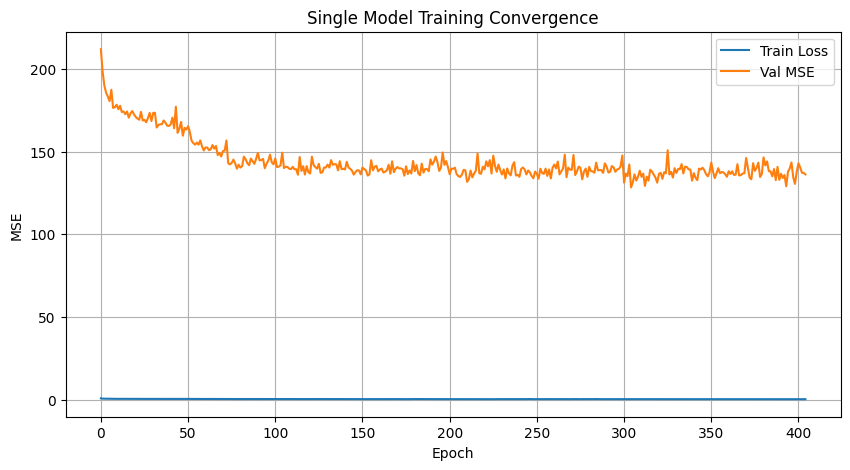

In [13]:
# --- 4. PLOT TRAINING HISTORY ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val MSE')
plt.title("Single Model Training Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.savefig("cup_pytorch_single_convergence.png")
plt.show()


In [14]:
# --- 5. FINAL EVALUATION (INTERNAL TEST) ---
# Load Best Model
print("Loading best model for evaluation...")
best_model_state = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(best_model_state)
model.eval()

# Evaluate on Internal Test Set
test_mse = training_utils.evaluate(model, test_loader, criterion, DEVICE, target_scaler=target_scaler)
test_mee = training_utils.evaluate_mee(model, test_loader, DEVICE, target_scaler=target_scaler)

print("="*40)
print(f"FINAL RESULT (Internal Test Set)")
print(f"MSE: {test_mse:.4f}")
print(f"MEE: {test_mee:.4f}")
print("="*40)

# Save Results to JSON
update_json("CUP", "PyTorch", {
    "internal_test_MEE": test_mee,
    "internal_test_MSE": test_mse,
    "best_val_MSE": best_val_loss
})


Loading best model for evaluation...
FINAL RESULT (Internal Test Set)
MSE: 123.7675
MEE: 20.0581


TypeError: Object of type float32 is not JSON serializable

In [ ]:
# --- EXTRA. TARGET DISTRIBUTION ANALYSIS (Scaled vs Unscaled) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 1. Recover Raw Targets from Train Loader
# We extract the Y tensor and move to numpy
y_train_scaled = train_loader.dataset.y.numpy()

# If targets were scaled in loader, we inverse transform them to get raw
if target_scaler:
    y_train_raw = target_scaler.inverse_transform(y_train_scaled)
else:
    y_train_raw = y_train_scaled

# 2. Define Scalers to Compare
scalers = {
    "Unscaled (Raw)": None,
    "StandardScaler (Z-score)": StandardScaler(),
    "MinMaxScaler (0-1)": MinMaxScaler(),
    "RobustScaler (Quantile)": RobustScaler()
}

# 3. Plot Distributions for each Target Dimension (Y1 to Y4)
num_targets = y_train_raw.shape[1]
fig, axes = plt.subplots(num_targets, len(scalers), figsize=(20, 4 * num_targets))

print("Generating Target Distribution Plots and Statistics...")

# Set pandas display options for better readability of the describe() output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.3f}'.format)

for dim_i in range(num_targets):
    target_name = f"Target_Y{dim_i+1}"
    
    # Dictionary to collect data for this target across all scalers for describe()
    comparison_data = {}

    for idx, (scaler_name, scaler_obj) in enumerate(scalers.items()):
        ax = axes[dim_i, idx]
        
        # Transform data
        if scaler_obj is None:
            data_to_plot = y_train_raw[:, dim_i]
        else:
            # Fit on full raw y and transform (we fit on all targets, then extract the specific dim)
            transformed_y = scaler_obj.fit_transform(y_train_raw)
            data_to_plot = transformed_y[:, dim_i]
            
        # Add to comparison dictionary
        comparison_data[scaler_name] = data_to_plot
        
        # Plot Histogram & KDE
        sns.histplot(data_to_plot, kde=True, ax=ax, color='skyblue', edgecolor='black')
        
        # Formatting
        ax.set_title(f"{target_name} | {scaler_name}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        
        # Add stats annotation (Mean/Std) to the plot
        mu = np.mean(data_to_plot)
        std = np.std(data_to_plot)
        ax.annotate(f"Mean: {mu:.2f}\nStd: {std:.2f}", 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    bbox=dict(boxstyle="round", fc="white", alpha=0.8),
                    verticalalignment='top')
    
    # --- PRINT DESCRIBE() TABLE FOR CURRENT TARGET ---
    print(f"\n{'='*20} STATISTICS FOR {target_name} {'='*20}")
    df_compare = pd.DataFrame(comparison_data)
    print(df_compare.describe())
    print("-" * 80)

plt.tight_layout()
plt.show()

Study 'mlcup_search' loaded successfully.
Total Trials: 150

BEST TRIAL RESULTS
  Value (Validation MSE): 158.078506
  Trial Number: 142
  Params:
    scaler: standard
    scale_target: True
    gaussian_noise: 0.061871255288155694
    hidden_size: 23
    dropout: 0.10931516958616493
    weight_decay: 1.1216990119294307e-06
    activation: relu
    lr: 0.0772411979336808

Top 10 Trials:


,number,value,scaler,scale_target,gaussian_noise,hidden_size,dropout,weight_decay,activation,lr
142,142,158.078506,standard,True,0.061871,23,0.109315,0.000001,relu,0.077241
149,149,158.166855,standard,True,0.072179,24,0.111896,0.000002,relu,0.081192
143,143,159.699066,standard,True,0.068043,24,0.107693,0.000001,relu,0.059982
85,85,162.084564,standard,True,0.003387,23,0.161565,0.000131,gelu,0.085105
101,101,162.287628,standard,True,0.055221,22,0.123492,0.000007,gelu,0.068315
123,123,162.413971,standard,True,0.059597,22,0.135812,0.000005,gelu,0.073860
112,112,162.898117,standard,True,0.057650,23,0.122032,0.000003,gelu,0.072080
105,105,163.029205,standard,True,0.063164,22,0.124111,0.000007,gelu,0.068266
141,141,163.956345,standard,True,0.061977,24,0.118140,0.000001,relu,0.061034
144,144,164.391205,standard,True,0.067811,23,0.106424,0.000001,relu,0.057393


/var/folders/q_/svzf5dgd69q5h8h686ps7qxw0000gn/T/ipykernel_52775/3489005384.py:50: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


<Figure size 1000x600 with 0 Axes>

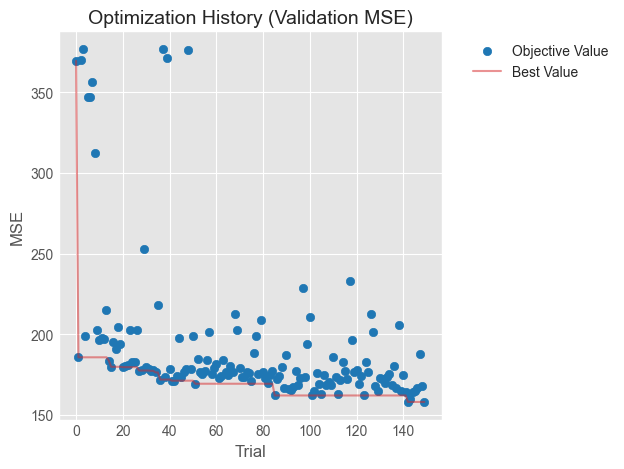

/var/folders/q_/svzf5dgd69q5h8h686ps7qxw0000gn/T/ipykernel_52775/3489005384.py:60: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


<Figure size 1000x600 with 0 Axes>

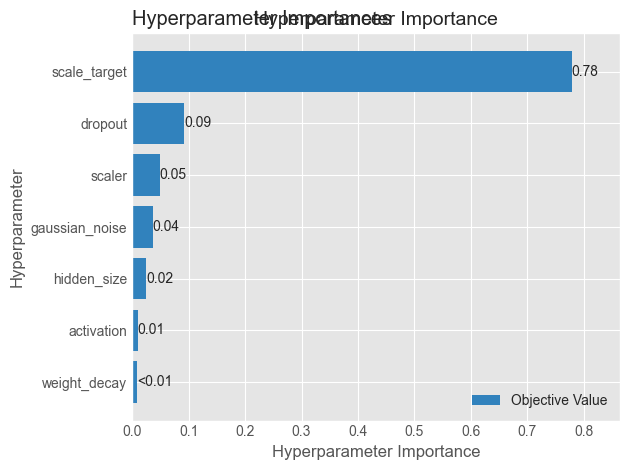

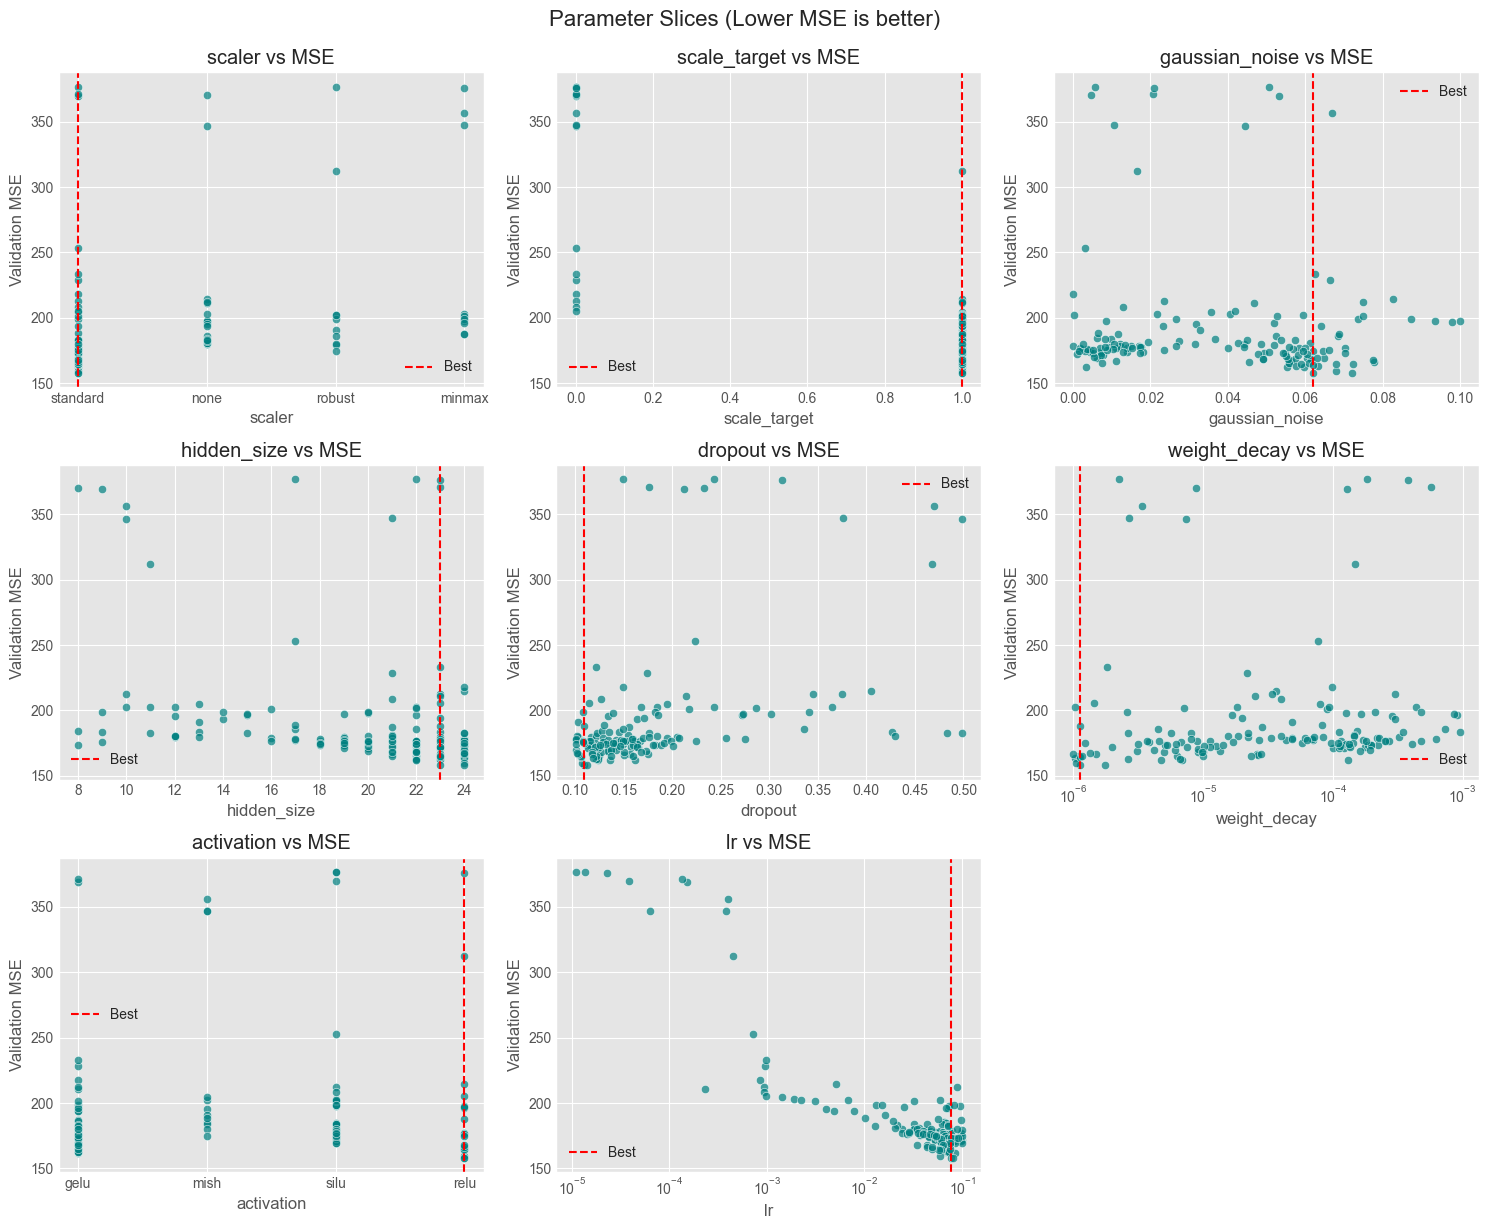

In [15]:
# --- EXTRA. OPTUNA RESULTS ANALYSIS & VISUALIZATION ---
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_slice

# 1. Load the Study
db_url = "sqlite:///optuna_mlcup_nn.db"
study_name = "mlcup_search"

try:
    storage = optuna.storages.RDBStorage(url=db_url)
    study = optuna.load_study(study_name=study_name, storage=storage)
    
    print(f"Study '{study_name}' loaded successfully.")
    print(f"Total Trials: {len(study.trials)}")
    
    # 2. Display Best Trial Details
    best_trial = study.best_trial
    print("\n" + "="*40)
    print("BEST TRIAL RESULTS")
    print("="*40)
    print(f"  Value (Validation MSE): {best_trial.value:.6f}")
    print(f"  Trial Number: {best_trial.number}")
    print("  Params:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")
    print("="*40 + "\n")

    # 3. Convert to DataFrame for Custom Analysis
    df = study.trials_dataframe()
    # Filter only complete trials
    df_success = df[df.state == "COMPLETE"].copy()
    
    # Rename columns for readability (remove 'params_' prefix)
    df_success.columns = [col.replace('params_', '') for col in df_success.columns]
    
    # Sort by value (MSE)
    top_10 = df_success.sort_values('value').head(10)
    print("Top 10 Trials:")
    display(top_10[['number', 'value'] + list(best_trial.params.keys())])

    # --- PLOTS ---
    # Set general style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # A. Optimization History (Did we converge?)
    plt.figure(figsize=(10, 6))
    plot_optimization_history(study)
    plt.title("Optimization History (Validation MSE)", fontsize=14)
    plt.xlabel("Trial")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()

    # B. Hyperparameter Importance (What matters most?)
    try:
        plt.figure(figsize=(10, 6))
        plot_param_importances(study)
        plt.title("Hyperparameter Importance", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot importance: {e}")

    # C. Slice Plots (Individual Parameter Trends)
    # We create a custom slice plot using Seaborn for better control than Optuna's default
    params_to_plot = list(best_trial.params.keys())
    n_params = len(params_to_plot)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, param in enumerate(params_to_plot):
        sns.scatterplot(data=df_success, x=param, y='value', ax=axes[i], alpha=0.7, color='teal')
        
        # Highlight best value
        best_val_param = best_trial.params[param]
        axes[i].axvline(best_val_param, color='red', linestyle='--', label='Best')
        
        axes[i].set_title(f"{param} vs MSE")
        axes[i].set_ylabel("Validation MSE")
        axes[i].legend()
        
        # Log scale for learning rate and weight decay usually looks better
        if param in ['lr', 'weight_decay']:
            axes[i].set_xscale('log')

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle("Parameter Slices (Lower MSE is better)", y=1.02, fontsize=16)
    plt.show()

except Exception as e:
    print(f"Error loading study or plotting: {e}")
    print("Make sure 'optuna_mlcup_nn.db' exists and 'optuna' is installed.")

# --- UTILITY: CONVERT OLD STUDIES TO CSV ---
"""
Use this cell to convert older SQLite-based Optuna studies into the new CSV format compatibility.
"""


In [ ]:
import optuna
import pandas as pd
import os
import json

def convert_study_to_csv(db_path, output_folder, study_name="mlcup_search"):
    if not os.path.exists(db_path):
        print(f"Database not found: {db_path}")
        return
        
    print(f"Loading study '{study_name}' from {db_path}...")
    try:
        storage = f"sqlite:///{db_path}"
        study = optuna.load_study(study_name=study_name, storage=storage)
        
        # Ensure output dir exists
        os.makedirs(output_folder, exist_ok=True)
        
        # 1. Save Trials CSV
        df = study.trials_dataframe()
        csv_path = os.path.join(output_folder, "optuna_results.csv")
        df.to_csv(csv_path, index=False)
        print(f"Trials saved to: {csv_path}")
        
        # 2. Save Best Params JSON
        try:
            best_params = study.best_params
            json_path = os.path.join(output_folder, "hp.json")
            with open(json_path, 'w') as f:
                json.dump(best_params, f, indent=4)
            print(f"Best Params saved to: {json_path}")
        except ValueError:
            print("Study has no completed trials. Optimization params skipped.")

    except Exception as e:
        print(f"Error converting study: {e}")

# Example Usage:
# Change 'output_folder' to save to a different directory (e.g., 'pytorch/models/optuna/experiment_v2')
# Change 'study_name' if you used a different name during search
convert_study_to_csv(
    db_path="optuna_mlcup_nn.db", 
    output_folder="pytorch/models/optuna/name", # <--- CHANGE THIS FOLDER NAME to avoid overwriting
    study_name="mlcup_search"
)


Loading study 'mlcup_search' from optuna_mlcup_nn.db...
Trials saved to: pytorch/models/optuna/20_01_2026(2layers)/optuna_results.csv
Best Params saved to: pytorch/models/optuna/20_01_2026(2layers)/hp.json


In [ ]:
# --- EXPERIMENTAL: TRAIN "BIG NETWORK" ON FULL DATA ---

# Ensure dependencies are available if running this cell alone
try:
    from torch.utils.data import TensorDataset, DataLoader
except ImportError:
    print("Importing torch modules locally...")
    import torch
    from torch.utils.data import TensorDataset, DataLoader

if 'train_loader' not in globals():
    print("Initializing Data Loader and Defaults...")
    from utils.data_loader import get_ml_cup_data
    
    BATCH_SIZE = 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    
    # Load FULL Training Data (including internal test set for maximum data)
    # Using test_ratio=0.2 to keep an internal eval set for MEE calculation
    train_loader, val_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
        BATCH_SIZE, 
        validation_ratio=0.0, # No validation set for this experiment, just Train/Test split
        test_ratio=0.2,       # Keep 20% for internal evaluation
        scale_target=True,
        num_workers=0
    )
    print(f"Data Loaded: Input={INPUT_SIZE}, Output={OUTPUT_SIZE}, Device={DEVICE}")

# Configurable Hyperparameters
EXP_EPOCHS = 1500
EXP_HIDDEN_SIZE = 16
EXP_LAYERS = 2
EXP_LR = 0.01
EXP_MOMENTUM = 0.9
EXP_WEIGHT_DECAY = 0.001
EXP_ACTIVATION = 'relu'

print(f"Training Experimental Network with: Hidden={EXP_HIDDEN_SIZE}, Layers={EXP_LAYERS}, Epochs={EXP_EPOCHS}, WD={EXP_WEIGHT_DECAY}...")

# 1. Prepare Data
# Using the training set from loader
X_train_exp = train_loader.dataset.X
y_train_exp = train_loader.dataset.y

# Create dataset/loader
exp_dataset = TensorDataset(X_train_exp, y_train_exp)
exp_loader = DataLoader(exp_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. Build Model
# Adjust architecture based on config
hidden_sizes = [EXP_HIDDEN_SIZE] * EXP_LAYERS
base = StandardFeedForwardNet(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, EXP_ACTIVATION)
model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)

# Optimizer
opt = torch.optim.SGD(model.parameters(), lr=EXP_LR, momentum=EXP_MOMENTUM, weight_decay=EXP_WEIGHT_DECAY, nesterov=True)
crit = torch.nn.MSELoss()

# 3. Train
train_loss_hist = []

for epoch in range(EXP_EPOCHS):
    model.train()
    batch_losses = []
    for x, y in exp_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())
    
    avg_loss = np.mean(batch_losses)
    train_loss_hist.append(avg_loss)
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EXP_EPOCHS} | Train MSE: {avg_loss:.5f}")

# 4. Evaluate (Internal Test)
model.eval()
test_mse = training_utils.evaluate(model, test_loader, crit, DEVICE, target_scaler=target_scaler)
test_mee = training_utils.evaluate_mee(model, test_loader, DEVICE, target_scaler=target_scaler)

print("\n" + "="*30)
print(f"EXPERIMENTAL RESULTS")
print("="*30)
print(f"Final Train MSE: {train_loss_hist[-1]:.5f}")
print(f"Internal Test MSE: {test_mse:.5f}")
print(f"Internal Test MEE: {test_mee:.5f}")
print("="*30)

# 5. Plot Training Curve
plt.figure(figsize=(10, 5))
plt.plot(train_loss_hist, label='Train MSE')
plt.title("Experimental Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
